<a href="https://colab.research.google.com/github/alejagamez26/GCI/blob/main/lec6_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6 Model Evaluation

**Chapter Introduction**

In this session, we explore a crucial step in the supervised learning workflows: **model evaluation**.
 <!-- **feature engineering**, and **ensembling** techniques.  -->
We'll cover different evaluation metrics for both classification and regression tasks. By the end, you'll be well-equipped to measure and evaluation of your models!


Goal:
To master various evaluation metrics for regression and classification.


## Table of contents

- **[6.1 Introduction](#6.1-Introduction)**
    - [6.1.1 Importing Libraries Used in This Chapter](#6.1.1)



- **[6.2 Evaluation Metrics for Classification Models](#6.2-Evaluation-Metrics-Classification)**
    - [6.2.1 Confusion Matrix and Related Indices](#6.2.1)
    - [6.2.2 ROC Curve and ROC-AUC Score](#6.2.2)

- **[6.3 Evaluation Metrics for Regression Models](#6.2-Evaluation-Metrics-Regression)**
    - [6.3.1 Evaluation Metrics for Regression Models](#6.3.1)


## 6.1 Introduction
### 6.1.1 Importing Libraries Used in This Chapter
This chapter will make use of various libraries. We will proceed under the assumption that the following libraries have been imported.

In [1]:
# Please ensure that the following libraries are imported in advance.
import numpy as np
import numpy.random as random
import pandas as pd
from pandas import Series, DataFrame
import warnings

# Display up to three decimal places
%precision 3

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

# Ignore warnings
warnings.filterwarnings('ignore')

## 6.2 Evaluation Metrics for Classification Models
Keywords: confusion matrix, accuracy, precision, recall, harmonic mean, F1 score, ROC, ROC-AUC



Next, let's consider metrics for classification models.

Classification tasks involve predicting discrete labels, such as “spam” vs “not spam,” and as a result, require specialized metrics to reflect different trade-offs and goals.

In section 6.2.1, we will first introduce **confusion matrix**. Then, derived from the confusion matrix, we will introduce metrics such as **accuracy**, **recall**, **precision**, the **F1 score**.

In section 6.2.2, we will focus on another metric, **ROC-AUC**., exploring how each metric provides a unique perspective on your model's strengths and limitations. We'll also learn how to compute these metrics using scikit-learn and interpret their values to guide model improvements.

Additionally, to understand these metrics, we will cover the **confusion matrix** and **ROC curve**. Finally, we will briefly introduce evaluation metrics for regression algorithms.

### 6.2.1 Confusion Matrix and Related Indices

#### Confusion Matrix

The **confusion matrix** is a fundamental matrix for evaluating classification models, representing the relationship between predicted and observed values. Specifically, it consists of four categories, as shown in the diagram below. The columns represent the predicted values (positive and negative), while the rows represent the observed values (positive and negative). The labels "positive" and "negative" in the predicted values are based on the predictions, while the observed values are classified as true or false based on their alignment with the predictions.

![image.png](https://miro.medium.com/v2/resize:fit:1400/1*VatH8Ym0EwAoKdRXfjefAQ.png)

Reference: https://medium.com/nerd-for-tech/getting-hold-of-confusion-matrix-1c8481a2107e


For example, if the prediction is positive and the actual value is also positive, it is considered a **True Positive**. Similarly, if the prediction is negative and the actual value is also negative, it is considered a **True Negative**. These two cases represent scenarios where our predictions were correct. In other cases (**False Positive** or **False Negative**), the predictions were incorrect.

Since this might be unclear, let's look at an example.

We will explain how to obtain a confusion matrix using the breast cancer dataset we previously handled (the cancer dataset). First, let's construct a classification model using a support vector machine (SVM). This classification model will return either a "0" (malignant) or a "1" (benign) to indicate whether the group is malignant or benign. Note that "0" and "1" are just labels and have no inherent numerical meaning.

We will first conduct a grid search over the hyperparameters, `gamma` and `C`.

Best score: 0.95
Parameter values (gamma, C) at best score: (np.float64(0.001), np.float64(10.0))


<Axes: >

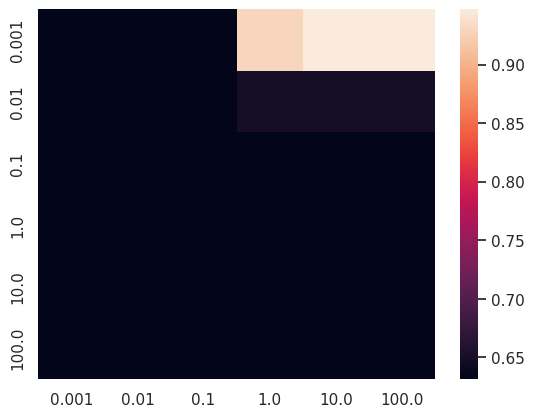

In [2]:
# Import from scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.tree import  DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split

# Load the breast cancer dataset (classification task)
cancer = load_breast_cancer(as_frame=True)

# Rename explanatory variables and target variable
X_cancer = cancer.data
y_cancer = cancer.target

# Step 1: split off 20% as the held-out test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2,        # 20% to test
    stratify=y_cancer,  random_state=42,
)

# Step 2: split the remaining 80% into train (70%) and validation (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=1/8,        # 1/8 of 80% = 10% of total
    stratify=y_train_val, # keep class balance in val too
    random_state=42,
)

# Create an array of values to search for in the hyperparameters
params_values = np.logspace(-3, 2, num=6)

# Build and validate the model for all combinations of hyperparameters
scores = {}
for gamma in params_values:
    for C in params_values:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train,y_train)
        # Record scores for each hyperparameter combination in the dictionary variable `scores`
        # For SVM and most other sklearn models
        scores[(gamma, C)] = svm.score(X_val, y_val)

# After finishing the for loop, convert the `scores` dictionary to a pandas Series
scores = pd.Series(scores)

# Display result
print(f'Best score: {scores.max():.2f}')
print(f'Parameter values (gamma, C) at best score: {scores.idxmax()}')

# Display a heatmap. The vertical axis shows gamma, and the horizontal axis shows C.
sns.heatmap(scores.unstack())

We will then train the model using the best hyperparameters.

In [3]:
# Initialize and train the model using best hyperparameters
model = SVC(gamma=scores.idxmax()[0], C=scores.idxmax()[1])
model.fit(X_train, y_train)

# Display results
print(f'SVC train score: {model.score(X_train,y_train):.3f}')
print(f'SVC test score: {model.score(X_test,y_test):.3f}')

SVC train score: 1.000
SVC test score: 0.877


Next, we will obtain the confusion matrix. The confusion matrix can be retrieved using the `confusion_matrix` function from the `sklearn.metrics` module. As shown in the earlier diagram, the output consists of predicted values (`y_pred`) arranged in columns and observed values (`y_test`) in rows, ordered as positive and negative examples.

In [4]:
# Import from scikit-learn
from sklearn.metrics import confusion_matrix

# Calculating Predicted Values Using the test data
y_pred = model.predict(X_test)

m = confusion_matrix(y_test, y_pred)
print(f'Confusion matrix:\n{m}')

Confusion matrix:
[[39  3]
 [11 61]]


When tabulated, the results will appear as follows.

|             | Predicted(0) | Predicted(1) |
|-------------|--------------|--------------|
| Observed(0) | 39           | 3            |
| Observed(1) | 11            | 61           |

Using this confusion matrix, we will explain **accuracy**, **precision**, **recall**, and **F1 score**.

#### Accuracy

Accuracy is the proportion of correct predictions out of the total predictions. While we have been calculating accuracy using the score method of Scikit-learn classes, it can also be computed using the confusion matrix, as shown below. Verify that the result matches the value obtained from the score method.

\begin{equation}
\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
\end{equation}

In [5]:
accuracy = (m[0, 0] + m[1, 1]) / m.sum()
print(f'Accuracy:{accuracy:.3f}')

Accuracy:0.877


From the calculation formula, accuracy is derived by summing the number of instances where the target variable was predicted as 0 and observed as 0 (48) and as 1 and observed as 1 (82), resulting in 48+82=130, and dividing this sum by the total number of instances in the matrix (143). Accuracy serves as an indicator of how well the model predicts both 1s and 0s overall.

#### Precision, Recall, and F1 Score


**Precision**: Precision measures the proportion of predicted positives that are actual positives. For example, in an anomaly detection system, it represents the proportion of alerts that correspond to real anomalies. In the above case, the model predicted 87 instances as positive (FP+TP=5+82=87), out of which 82 were actually positive (TP). Therefore, precision is 82/87≈0.943.

\begin{equation}
\text{Precision} = \frac{TP}{TP+FP}
\end{equation}


**Recall**: Recall measures the proportion of actual positives that were correctly predicted as positive. For example, in a disease diagnosis system, a recall of 100% indicates that all actual cases of the disease were identified. In the above case, there are 90 observed positive instances (FN+TP=8+82=90), of which 82 were correctly predicted (TP). Thus, recall is 82/90≈0.911.

\begin{equation}
\text{Recall} = \frac{TP}{TP+FN}
\end{equation}

**F1 Score**: The F1 score is the harmonic mean of precision and recall. It is used when there is no clear priority between precision and recall, providing an overall evaluation of the model. The harmonic mean is calculated as 2/(1/precision+1/recall)=2/(1/0.943+1/0.911)≈0.927. For a deeper understanding of harmonic means, refer to the introductory sections of statistical textbooks.

\begin{equation}
F_1 = \frac{2}{1/\text{recall}+1/\text{precision}}
\end{equation}

The formulas for calculating these three metrics using the elements of the confusion matrix are as follows:

In [6]:
# Calculate precision
precision = (m[1, 1]) / m[:, 1].sum()

# Calculate recall
recall = (m[1, 1]) / m[1, :].sum()

# Calculate F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')

Precision: 0.953
Recall: 0.847
F1 Score: 0.897


These values can also be calculated using Scikit-learn functions, which is a simpler approach. The above calculations were performed step-by-step for conceptual understanding, but once you're familiar with them, you can code as shown below. Ensure the calculated values match those obtained above.

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

# All functions take the ground truth values as the first argument and the predicted values as the second argument
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the scores
print(f'Precision:{precision:.3f}')
print(f'Recall:{recall:.3f}')
print(f'F1 Score:{f1:.3f}')

Precision:0.953
Recall:0.847
F1 Score:0.897


#### <Practice Question 6-1>
Using the breast cancer dataset, build a logistic regression model. Generate a confusion matrix for the model and calculate the accuracy, precision, recall, and F1 score values for the test dataset using Scikit-learn functions.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = LogisticRegression(random_state=0, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'Accuracy:{accuracy_score(y_test, y_pred):.3f}')
# Initialize and train the model

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

### 6.2.2 ROC Curve and ROC-AUC Score

The confusion matrix introduced in the previous section assumes that prediction results are labeled as either positive or negative. However, when evaluating a model, the threshold for dividing predicted labels may not always be predetermined. In other words, there are cases where you may want to evaluate a model's performance based on the relationship between predicted probabilities (instead of predicted labels) and observed values (1 or 0). In such cases, the **ROC curve** and **ROC-AUC** introduced in this section are useful tools.

#### ROC Curve

The **ROC (receiver operating characteristic) curve** is a plot of the **true positive rate (TPR)** on the vertical axis and the **false positive rate (FPR)** on the horizontal axis.


TPR is the proportion of actual positives correctly predicted as positive (equivalent to recall).
FPR is The proportion of actual negatives incorrectly predicted as positive.
By gradually changing the threshold used to convert predicted probabilities into predicted labels from 0.0 to 1.0, you can plot the relationship between TPR and FPR to create the ROC curve.

<!-- ![drawing](https://miro.medium.com/v2/resize:fit:1200/1*Bgc9QOjhnL70g2SQxyj6hQ.png) -->
<img src="https://miro.medium.com/v2/resize:fit:1200/1*Bgc9QOjhnL70g2SQxyj6hQ.png" alt="ROC" width="500"/>


Reference: https://medium.com/@ilyurek/roc-curve-and-auc-evaluating-model-performance-c2178008b02


To understand what it means to draw the ROC curve by varying the threshold, let's examine this using the breast cancer dataset.

The `predict_proba` method outputs an array of predicted probabilities for each class rather than binary labels (0 or 1). In this example, we consider malignant (0) as the positive class and benign (1) as the negative class.

In [8]:
# Import
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
model = LogisticRegression(random_state=0, max_iter=10000)
model.fit(X_train, y_train)

# Calculate predicted probabilities for the test data
# `predict_proba` outputs a 2D array where axis=1 index 0 holds probabilities for the negative class, and index 1 holds probabilities for the positive class.
# `[:, 1]` is used here to extract the probabilities for the positive class.
results = pd.DataFrame(model.predict_proba(X_test), columns=cancer.target_names)

# Display the first five rows of predicted probabilities
results.head()

,malignant,benign
0,1.000000,9.183422e-12
1,0.000020,9.999799e-01
2,0.920949,7.905128e-02
3,0.413940,5.860603e-01
4,1.000000,1.215108e-08


To determine the predicted labels (malignant: 0 or benign: 1) from predicted probabilities, you need to set a **threshold**, a value that devides a sample to be predicted positive/negative. Naively, a threshold of 50% (0.5) might seem appropriate for decision-making. However, in practice, the threshold is set based on the intended purpose of the model and the natural occurrence rate of the positive class.

The shift of threshold value affects the number of samples predicted as positive and negative, consequently changing the values of the accuracy, precision, and recall. For example, consider four cases with thresholds set at 0.4, 0.3, 0.15, and 0.05. By focusing on the predicted probabilities of the benign class (positive class), you can create a flag variable where predictions exceeding the threshold are assigned 1, and those below it are assigned 0.

In [9]:
# Set 1 for benign (class 1) predictions where the probability is 0.4, 0.3, 0.15, or 0.05 or higher
for threshold in [0.4, 0.3, 0.15, 0.05]:
    results[f'flag_{threshold}'] = results['benign'].map(lambda x: 1 if x > threshold else 0)

# # Display the first ten rows of predicted probabilities
results.head(10)

,malignant,benign,flag_0.4,flag_0.3,flag_0.15,flag_0.05
0,1.000000,9.183422e-12,0,0,0,0
1,0.000020,9.999799e-01,1,1,1,1
2,0.920949,7.905128e-02,0,0,0,1
3,0.413940,5.860603e-01,1,1,1,1
4,1.000000,1.215108e-08,0,0,0,0
5,0.013065,9.869349e-01,1,1,1,1
6,0.000010,9.999903e-01,1,1,1,1
7,0.999998,2.185579e-06,0,0,0,0
8,0.999954,4.581806e-05,0,0,0,0
9,1.000000,1.391577e-11,0,0,0,0


By creating prediction flags from probabilities and thresholds in this way, you can generate a confusion matrix with observed values and calculate the false positive rate and true positive rate for each threshold.

The four threshold cases mentioned above only provide a limited view of the ROC curve. To plot a more complete ROC curve, consider thresholds ranging from 0.01 to 0.99 in 50 increments. Using these thresholds, you can calculate the false positive rate and true positive rate for each case and plot them.

<Axes: xlabel='false positive rate', ylabel='true positive rate'>

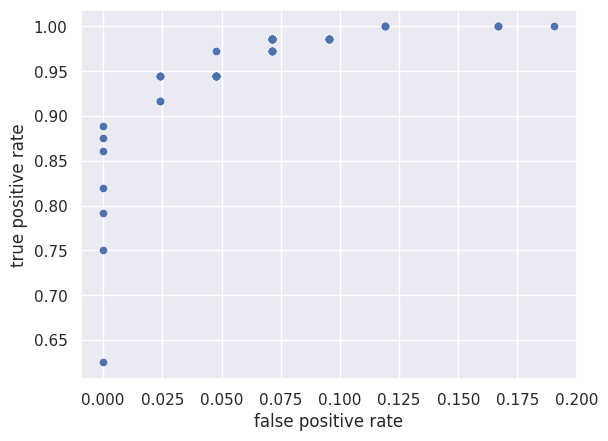

In [10]:
# Compute false positive rate and true positive rate for 50 thresholds between 0.01 and 0.99
rates = {}
for threshold in np.linspace(0.01, 0.99, num=50):
    labels = results['benign'].map(lambda x: 1 if x > threshold else 0)
    m = confusion_matrix(y_test, labels)
    rates[threshold] = {'false positive rate': m[0,1] / m[0, :].sum(),
                         'true positive rate': m[1,1] / m[1, :].sum()}

# Plot with the false positive rate on the x-axis and the true positive rate on the y-axis
pd.DataFrame(rates).T.plot.scatter('false positive rate', 'true positive rate')

To simplify the process of drawing the ROC curve, you can use the `roc_curve` function from the `sklearn.metrics` module.

Here, we'll use the breast cancer dataset to build a support vector machine (SVM) model and obtain predicted probabilities (`y_pred`).

In [11]:
# Import from scikit-learn
from sklearn import svm
from sklearn.metrics import roc_curve

# Obtain predicted probabilities using SVC
# Note: Ensure the `probability` argument is set to True during SVC initialization to use the `predict_proba` method later.
model = svm.SVC(kernel='linear', probability=True, random_state=0)
model.fit(X_train, y_train)

# Get predicted probabilities
# `predict_proba` outputs a 2D array where axis=1 index 0 holds probabilities for the negative class, and index 1 holds probabilities for the positive class.
# `[:, 1]` is used here to extract the probabilities for the positive class.
y_pred = model.predict_proba(X_test)[:, 1]

Once you have obtained the predicted probabilities (`y_pred`), you can pass them along with the observed values (`y_test`) to the `roc_curve` function from the `sklearn.metrics` module. This function returns arrays for the false positive rate (FPR) and true positive rate (TPR) as outputs, which can then be used for plotting. The actual calculations and plotting will be demonstrated in the next section.

#### ROC-AUC

The area under the ROC curve is a very important index to measure the model performance and is called literally the **ROC-AUC (area under curve)**.



Below, we plot the ROC curve as a red solid line. We also plot the ROC curve for a random model, represented by a black dashed line. The ROC-AUC value can be obtained by passing FPR and TPR (in this order) to the `auc` function from the `sklearn.metrics` module.

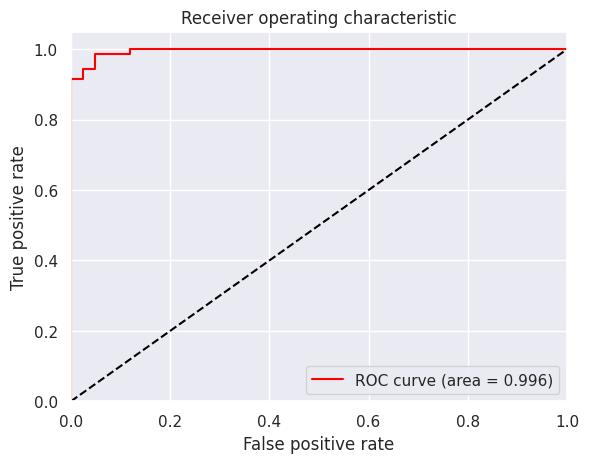

In [12]:
from sklearn.metrics import roc_curve, auc

# Compute false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate AUC
auc_value = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, color='red', label='ROC curve (area = %.3f)' % auc_value)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="best")

While we've shown detailed calculation steps to help you understand the nature of the ROC-AUC, Scikit-learn also provides functions to simplify this process.<br>
Once you understand the concept, you can use these functions for practical applications.

In [13]:
# Import the function to directly calculate ROC-AUC
from sklearn.metrics import roc_auc_score

# Similar to other scoring functions, pass the observed values as the first argument and the predicted probabilities as the second argument
roc_auc_score(y_test, y_pred)

np.float64(0.9957010582010581)

#### Ideal ROC Curve and AUC

The shape of an ideal ROC curve would show the true positive rate increasing first (as the threshold decreases from a value greater than 1.0), moving vertically from the origin to the coordinate (0, 1), and then horizontally to the coordinate (1, 1).

In contrast, for random predictions, both the true positive rate and false positive rate increase equally, resulting in a straight diagonal line from the origin with a slope of 1. Models built using machine learning are typically expected to fall between the random line and the ideal curve, with a bulging shape indicating better performance.

The AUC is a model evaluation metric derived from the shape of the ROC curve, representing the area under the curve. An ideal curve has an AUC of 1.0, while random predictions have an AUC of 0.5.

In the example above, the AUC is 0.992, indicating that the model performs significantly better than random predictions.

Creating confusion matrices, comparing ROC curve shapes, and analyzing precision, recall, F1 scores, and AUC values are foundational for selecting models. However, it is important to note that these metrics only provide a relative ranking among candidate models. Avoid focusing solely on numerical metrics without considering the potential business outcomes of using the model. Understanding the relationship between model performance and business impact is crucial.

#### Using AUC for Imbalanced Data

Lastly, let's discuss the utility of AUC in handling imbalanced data. As noted in section 6.2.2, confusion matrices cannot be uniquely determined when thresholds are unclear. AUC can help address imbalanced datasets effectively.

For example, imagine that 5% of customers in a supermarket purchase product A. If a predictive model is created and the top 5 individuals with the highest predicted probabilities are flagged as likely to purchase product A, but none of them actually purchase it, the confusion matrix would look as follows. Here, we assume a total population of 100 individuals.

|             | Predicted(0) | Predicted(1) |
|-------------|--------------|--------------|
| Observed(0) | 90           | 5            |
| Observed(1) | 5            | 0            |

In this case, the precision is 0%, but the accuracy is 90%. If the model's performance is evaluated solely based on accuracy, a 90% accuracy might seem to indicate a good model. However, since the target is to predict the buyers, a model with 0% precision cannot be considered a meaningful result.

As in the example where "5 out of 100 people are buyers," accuracy is not a suitable metric under conditions where sample sizes are imbalanced between classes. On the other hand, AUC accounts for class imbalance because both fpr (false positive rate) and tpr (true positive rate) incorporate the sample sizes as their denominators. Thus, AUC is a robust metric for evaluating models under imbalanced data conditions.

#### <Practice Question 6-2>

Using the iris dataset, build a multi-class classification model using SVC with iris.target as the target variable. Calculate the ROC curve and AUC for the model. To create a multi-class classification model, use the `OneVsRestClassifier` class from the `sklearn.multiclass` module.

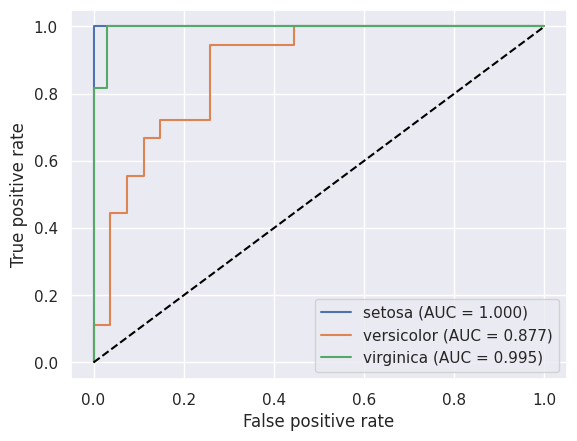

In [26]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Load the iris dataset

iris = load_iris()
X = iris.data
y = iris.target
y_bin = label_binarize(y, classes=[0, 1, 2])

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=0)

model = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=0))
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)

for i, name in enumerate(iris.target_names):
    fpr, tpr, thresholds = roc_curve(y_test[:, i], y_pred[:, i])
    auc_value = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc="best")
plt.show()


# Initialize and train the model

In [21]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

#### Advanced: Logloss

`Logloss` is another major metric for evaluating classification tasks. Although detailed explanations are omitted here, logloss is used to measure the error between the probabilities output by a classification model and the actual labels.

For example, when evaluating a binary classification model with accuracy, a prediction of 0.7 or 0.9 (using methods like predict_proba) would both be treated equally as `1 (positive class)` if a threshold of 0.5 is applied. However, if the true label is `1`, a prediction of 0.9 (higher confidence) should be rated higher than 0.7. While accuracy cannot distinguish such differences, logloss can, making it a more nuanced evaluation metric.

Like other evaluation metrics, logloss can be easily computed using [Scikit-learn's library](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html). Explore more about logloss for deeper understanding.

>**[Let's try it]**
>
>Explore more about logloss for deeper understanding.

**Acknowledgments:**<br>
The following datasets were used under the following terms:
1. http://lib.stat.cmu.edu/datasets/boston

Reference: The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic prices and the demand for clean air', J. Environ. Economics & Management, vol.5, 81-102, 1978. Used in Belsley, Kuh & Welsch, 'Regression Diagnostics: Identifying Influential Data and Sources of Collinearity', Wiley, 1980.

>**[Let's try it]**
>
>- Observe the results of the two models above. What do you notice? You should be able to identify specific issues that are not apparent from metrics based solely on averages or medians. Consider the trends that can be inferred from these observations.
>- Using the data from the second competition, create similar plots and examine the trends in model predictions.

## 6.3 Evaluation Metrics for Regression Models
Keywords: MSE, RMSE, MAE, MedAE, confusion matrix, accuracy, precision, recall, harmonic mean, F1 score, ROC, ROC-AUC

Machine learning models are rarely judged on accuracy alone. We need well-defined measures of success that reflect how our model performs under real-world conditions. In this section, we will explore evaluation metrics for both **regression** tasks and **classification** tasks. Each of these metrics highlights different strengths and weaknesses in a model's performance.

By the end of this section, you will understand why selecting the right metric is often just as important as choosing the right model. You will also learn how these metrics can reveal hidden problems like imbalanced datasets or overly large errors. Armed with this knowledge, you will be able to make more informed decisions about which metric aligns best with your goals and how to interpret the results effectively.

### 6.3.1 Evaluation Metrics for Regression Models

Regression tasks revolve around predicting continuous numeric values, from house prices to stock prices. To fairly judge how well a model is performing, we need metrics that measure the distance between the model's predictions and the actual values in a meaningful way.

The main evaluation indices are as follows.

#### **Mean Squared Error (MSE)**
The difference between predicted values and actual values (residuals) squared and summed for each sample is called the Sum of Squared Errors (SSE). Dividing the SSE by the number of samples gives the Mean Squared Error (MSE). MSE is a simple and intuitive metric, making it widely used for evaluating the performance of various algorithms.

\begin{equation}
\text{MSE} = \frac{1}{N}\sum_{i=1}^N |y_i - \hat{y}_i |^2
\end{equation}

#### **Root Mean Squared Error (RMSE)**
RMSE is the square root of the Mean Squared Error. Since the MSE involves squaring the residuals, its value differs from the original scale of the data. Therefore, RMSE is used in scenarios where it is important to align the scale of the metric with the original data for interpretation.

\begin{equation}
\text{RMSE} = \sqrt \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i |^2
\end{equation}

#### **Mean Absolute Error (MAE)**
MAE is calculated by summing the absolute values of residuals for each sample and then dividing by the number of samples. Unlike MSE, MAE does not square the residuals, making it less sensitive to outliers in predictions.

\begin{equation}
\text{MAE} = \frac{1}{N}\sum_{i=1}^N |y_i - \hat{y}_i |
\end{equation}

#### **Median Absolute Error (MedAE)**
MedAE is the median of the absolute values of the residuals. Compared to MAE, MedAE is an even more robust evaluation metric against outliers.

\begin{equation}
\text{MedAE} = \operatorname{Median}( |y_1 - \hat{y}_1|, |y_2-\hat{y}_2|, \cdots, |y_N-\hat{y}_N| )
\end{equation}

#### **$R^{2}$**
$R^{2}$is the ratio of the sum of squared totals (SST) of the model residuals to the sum of squared errors (SSE) when forecasting on the mean of the validation data, defined as $R^{2}=1-SSE/SST$.

It is a measure of how much squared error has been removed for the most naïve forecast, the mean forecast, and is 1.0 if all errors are eliminated, and 0.0 if it is equal to the mean forecast. The range of $R^{2}$ usually takes values between 0 and 1, but keep in mind that it can be negative.

\begin{equation}
R^2 = 1 - \frac{\sum_{i=1}^N |y_i - \hat{y}_i |^2 }{ \sum_{i=1}^N |y_i - \bar{y}_i |^2 }, ~~ \text{where } \bar{y} = \frac{1}{N}\sum_{i=1}^N y_i
\end{equation}

#### Comparing evaluation metrics
We need to use proper evaluation metrics depending on the target we want to achieve with the model. In situations where large prediction errors are of particular concern, MSE is preferred, while MAE is suitable when focusing on the average magnitude of errors. When using MSE but needing to interpret errors on the original scale of the data, RMSE is a better choice. Although MedAE is less commonly used compared to MSE and MAE, it can be a viable option when there is a strong need to completely ignore outliers in errors. In such cases, it is recommended to review both MAE and MSE alongside MedAE.

R-squared (R²) is useful for understanding how well a model explains a given dataset or for comparing the difficulty levels of different datasets.

It is not necessary to limit the evaluation to a single metric. In many cases, multiple evaluation metrics are calculated simultaneously to comprehensively assess a model's performance.

Let's explore how to use evaluation metrics in regression models using the Housing dataset, a sample dataset for regression tasks.

The Housing dataset includes features for different districts in California (e.g., average number of rooms per household and median income) and the median housing price (`MedHouseVal`) in units of $100,000 as the target variable. Below is the output of the first five rows of the data.

In [14]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing Price dataset (regression task)
california_housing = fetch_california_housing(as_frame=True)

# Rename explanatory variables and target variable
X_housing = california_housing.data
y_housing = california_housing.target

# Combine explanatory variables and target variable, and display the first five rows
pd.concat([X_housing, y_housing], axis=1).head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In the following example, we use `MedHouseVal` as the target variable to build models using:

- Multiple Linear Regression (LinearRegression)
- Ridge Regression (Ridge)
- Decision Tree Regressor (DecisionTreeRegressor)
- Linear Support Vector Regression (LinearSVR)

For each model, the evaluation metrics MSE, MAE, MedAE, and R² are calculated. The evaluation process employs the holdout method.

The evaluation metrics are all imported from `scikit-learn`. All functions take two arguments, true values as the first argument and the predicted values as the second argument.

In [15]:
# Import from scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score

# Split into training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, test_size=0.5, random_state=0)

# Standardize the data
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

# Model configuration
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=0),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=0),
    'LinearSVR': LinearSVR(random_state=0, max_iter=10000)
}

# Calculate the evaluation metrics
scores = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Each function takes the true values as the first argument and the predicted values as the second argument
    scores[(model_name, 'MSE')] = mean_squared_error(y_test, y_pred)
    scores[(model_name, 'MAE')] = mean_absolute_error(y_test, y_pred)
    scores[(model_name, 'MedAE')] = median_absolute_error(y_test, y_pred)
    scores[(model_name, 'R2')] = r2_score(y_test, y_pred)

# Display results
pd.Series(scores).unstack()

,MAE,MSE,MedAE,R2
DecisionTreeRegressor,0.486836,0.563154,0.289500,0.579518
LinearRegression,0.533041,0.534010,0.414231,0.601279
LinearSVR,0.518601,3.430819,0.343333,-1.561637
Ridge,0.533038,0.534025,0.414267,0.601268


From the results above, **MAE** and **MedAE** show that the decision tree performed better. However, for **MSE** and **R² scores**, the linear regression and ridge regression models outperformed the decision tree.  

This suggests that while the decision tree achieved more accurate predictions for the majority of records, it also likely produced significant outliers compared to the linear regression model.  

The linear support vector regression (LinearSVR) showed a negative **R² score**, indicating that significant adjustments to the default hyperparameters would be necessary to make it effective for this task.  

In this example, evaluation metrics were obtained using the holdout method. However, these metrics can also be obtained using cross-validation. In the case of k-fold cross-validation, you can use the `scoring` parameter of the `cross_val_score` function to customize the return values. For more details, refer to the official Scikit-learn documentation.

#### Side Note: Toward More Thorough Model Validation
So far, we have introduced various evaluation metrics. However, for more thorough model validation, it is important not to stop at simply reviewing the evaluation metrics. Instead, directly plotting and observing the relationship between the true values and predicted values can provide valuable insights.

For example, let's plot the prediction results of the linear regression model and the decision tree model for California housing prices. On the X-axis, place the predicted values, and on the Y-axis, place the true values.

First, we will define the plotting function in advance so that we can plot the result easily.

In [ ]:
# Define a function in advance for repeated visualization logic
def plot_pred_vs_actual(model, title):
    """Function to plot a scatter plot of predicted values vs. true values

    Args:
        model (BaseEstimator): The model used to generate predicted values.
        title (str): The title to display on the graph.
    """
    # Place predicted values on the X-axis and true values on the Y-axis
    y_pred = model.predict(X_test)
    sns.scatterplot(x=y_pred, y=y_test, alpha=0.4)
    # Display a red dashed line as a reference for perfect agreement between predicted and true values
    plt.plot([0, 10], [0, 10], color='red', linestyle='dashed')
    # Set graph parameters
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xlim(-5, 5.2)
    plt.ylim(0, 5.2)

Now, we will train the models and plot the results.

In [ ]:
# Create and train models
linear = LinearRegression().fit(X_train, y_train)
tree = DecisionTreeRegressor(random_state=0).fit(X_train, y_train)

plt.figure(figsize=(10, 3.5))

# Linear Regression graph
plt.subplot(1, 2, 1)
plot_pred_vs_actual(linear, 'LinearRegression')  # Execute the function defined above

# Decision Tree Regressor graph
plt.subplot(1, 2, 2)
plot_pred_vs_actual(tree, 'DecisionTree')  # Execute the function defined above

# Display the graph
plt.tight_layout()
plt.show()